In [6]:
import pyccl as ccl
import matplotlib.pyplot as plt
import numpy as np
import fitsio
import scienceplots
plt.style.use(['science','notebook','grid'])
from astropy.table import Table
import glob
from scipy.optimize import curve_fit as cf



In [7]:
matched_dr=Table(fitsio.FITS('/user/animesh.sah/DESI_PECVEL/DR_matched.fits')[1].read())

from scipy.stats import gaussian_kde
kde = gaussian_kde(matched_dr['Z'],bw_method=0.25)
samples = kde.resample(700).flatten()
samples = np.clip(samples, 0, None)
y_samples=kde.evaluate(samples)
samples_sorted=np.sort(samples)
arg=np.argsort(samples)
y_samples_sorted= y_samples[arg]


z=samples_sorted
n_z=y_samples_sorted
n_z /= np.trapz(y_samples_sorted, samples_sorted)
from astropy.cosmology import Planck18 as cosmo
import astropy.units as u
dL = cosmo.comoving_distance(samples_sorted).to(u.Mpc).value
num  = np.trapz(dL*n_z**2, z)
denom  = np.trapz(n_z**2, z)
chi_eff = num/denom
def theta_to_r(theta_deg):
    return chi_eff * np.deg2rad(theta_deg)

def r_to_theta(r_mpc):
    return np.rad2deg(r_mpc / chi_eff)


zeff = np.trapz(z*n_z, z) /np.trapz(n_z, z)
print('zeff = ', zeff)
dc_zeff= cosmo.comoving_distance(zeff).to(u.Mpc).value
dc_zeff

def theta_to_r_dc(theta_deg):
    return dc_zeff * np.deg2rad(theta_deg)
def r_to_theta_dc(r_mpc):
    return np.rad2deg(r_mpc / dc_zeff)

cosmo_hmcode = ccl.Cosmology(
    Omega_c=0.264,  # Cold dark matter density
    Omega_b=0.049,  # Baryon density
    h=0.674,        # Hubble parameter
    sigma8=0.811,    # Power spectrum normalization
    n_s=0.965       # Spectral index,
    ,matter_power_spectrum="camb",
    
    extra_parameters={
        "camb": {
            "halofit_version": "mead2020",

        }
    }

)

cosmo_halofit = ccl.Cosmology(
    Omega_c=0.264,  # Cold dark matter density
    Omega_b=0.049,  # Baryon density
    h=0.674,        # Hubble parameter
    sigma8=0.811,    # Power spectrum normalization
    n_s=0.965       # Spectral index
)


theta = np.logspace(np.log10(1e-2), np.log10(15), 40) # degrees


bias = np.ones_like(z) * 1
ell = np.arange(2, 2000)
tr_hm = ccl.NumberCountsTracer(cosmo_hmcode, dndz=(z, n_z), bias=(z, bias),has_rsd=False)
cl_hm = ccl.angular_cl(cosmo_hmcode, tr_hm, tr_hm, ell)
wtheta_hm = ccl.correlation(theta = theta, ell = ell, C_ell = cl_hm, cosmo = cosmo_hmcode)




zeff =  0.0921169750213109


In [9]:
def w_theta_func(theta,a):
    bias = a*np.ones_like(z) #+ 0.5*z
    tr_hm = ccl.NumberCountsTracer(cosmo_hmcode, dndz=(z, n_z), bias=(z, bias),has_rsd=False)
    cl_hm = ccl.angular_cl(cosmo_hmcode, tr_hm, tr_hm, ell)
    wtheta_hm = ccl.correlation(theta = theta, ell = ell, C_ell = cl_hm, cosmo = cosmo_hmcode)
    return wtheta_hm

def w_theta_func_halofit(theta,a):
    bias = a*np.ones_like(z) #+ 0.5*z
    tr = ccl.NumberCountsTracer(cosmo_halofit, dndz=(z, n_z), bias=(z, bias),has_rsd=False)
    cl = ccl.angular_cl(cosmo_halofit, tr, tr, ell)
    wtheta = ccl.correlation(theta = theta, ell = ell, C_ell = cl, cosmo = cosmo_halofit)
    return wtheta

In [8]:

full_no_weights = np.load('/user/animesh.sah/w_theta_results/treecorr_full_0.01_to_15_w_False_no_weights.npy')
full_pp = np.load('/user/animesh.sah/w_theta_results/treecorr_full_0.01_to_15_w_True_pp.npy')
full_equal_10 = np.load('/user/animesh.sah/w_theta_results/treecorr_full_0.01_to_15_w_True_equal_10.npy')
full_equal_5 = np.load('/user/animesh.sah/w_theta_results/treecorr_full_0.01_to_15_w_True_equal_5.npy')
full_full = np.load('/user/animesh.sah/w_theta_results/treecorr_full_0.01_to_15_w_True_full.npy')


full_cf_no_weights = np.load('/user/animesh.sah/w_theta_results/corrfunc_full_0.01_to_15_w_False_no_weights.npy')
full_cf_pp = np.load('/user/animesh.sah/w_theta_results/corrfunc_full_0.01_to_15_w_True_partial_percentile.npy')
full_cf_equal_10 = np.load('/user/animesh.sah/w_theta_results/corrfunc_full_0.01_to_15_w_True_equal_10.npy')
full_cf_equal_5 = np.load('/user/animesh.sah/w_theta_results/corrfunc_full_0.01_to_15_w_True_equal_5.npy')
full_cf_full = np.load('/user/animesh.sah/w_theta_results/corrfunc_full_0.01_to_15_w_True_full_sample.npy')


north_cf_no_weights = np.load('/user/animesh.sah/w_theta_results/corrfunc_north_0.01_to_15_w_False_no_weights.npy')
north_cf_pp = np.load('/user/animesh.sah/w_theta_results/corrfunc_north_0.01_to_15_w_True_partial_percentile.npy')
north_cf_equal_5 = np.load('/user/animesh.sah/w_theta_results/corrfunc_north_0.01_to_15_w_True_equal_5.npy')
north_cf_full = np.load('/user/animesh.sah/w_theta_results/corrfunc_north_0.01_to_15_w_True_full_sample.npy')

south_cf_no_weights = np.load('/user/animesh.sah/w_theta_results/corrfunc_south_0.01_to_15_w_False_no_weights.npy')
south_cf_pp = np.load('/user/animesh.sah/w_theta_results/corrfunc_south_0.01_to_15_w_True_partial_percentile.npy')
south_cf_equal_5 = np.load('/user/animesh.sah/w_theta_results/corrfunc_south_0.01_to_15_w_True_equal_5.npy')
south_cf_full = np.load('/user/animesh.sah/w_theta_results/corrfunc_south_0.01_to_15_w_True_full_sample.npy')


#south_no_weights = np.load('/user/animesh.sah/w_theta_results/treecorr_south_0.01_to_15_w_False_no_weights.npy')

north_pp = np.load('/user/animesh.sah/w_theta_results/treecorr_north_0.01_to_15_w_True_partial_percentile.npy')
north_equal_5 = np.load('/user/animesh.sah/w_theta_results/treecorr_north_0.01_to_15_w_True_equal_5.npy')
north_full = np.load('/user/animesh.sah/w_theta_results/treecorr_north_0.01_to_15_w_True_full_sample.npy')


south_pp = np.load('/user/animesh.sah/w_theta_results/treecorr_south_0.01_to_15_w_True_partial_percentile.npy')
south_equal_5 = np.load('/user/animesh.sah/w_theta_results/treecorr_south_0.01_to_15_w_True_equal_5.npy')
south_full = np.load('/user/animesh.sah/w_theta_results/treecorr_south_0.01_to_15_w_True_full_sample.npy')




array([5.57500696, 5.21635506, 4.68121853, 4.37093026, 3.92379973,
       3.52884465, 3.18018649, 2.91133579, 2.60587656, 2.4007286 ,
       2.11135212, 1.93791502, 1.72957926, 1.54517811, 1.36782037,
       1.23061015, 1.07965695, 0.94772125, 0.83437322, 0.72998284,
       0.63480276, 0.54756343, 0.47477814, 0.4149922 , 0.36376977,
       0.31632832, 0.28438512, 0.25496926, 0.22596372, 0.20628981,
       0.18819026, 0.17161204, 0.15486542, 0.14111354, 0.12821026,
       0.11542866, 0.10499031, 0.09348561, 0.08258871, 0.07344982,
       0.0609862 , 0.05084849, 0.04313889, 0.0379978 , 0.03206764,
       0.02693726, 0.02226246, 0.01785646, 0.01340571, 0.01035041])

/tmp/ipykernel_2649888/3770835145.py:11: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(fontsize=15)


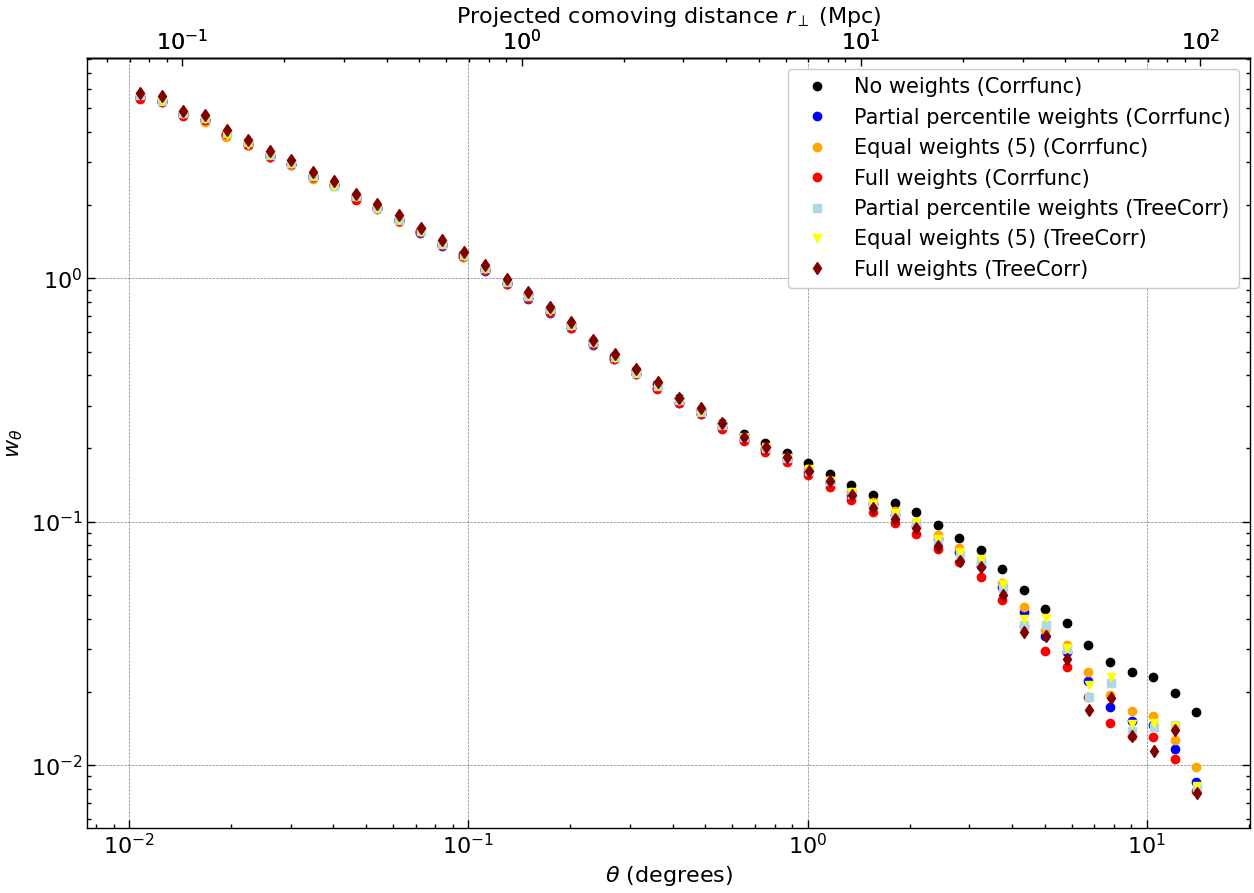

In [10]:
fig, ax = plt.subplots(figsize=(15,10))



ax.set_xlabel(r'$\theta$ (degrees)')

ax.set_ylabel(r'$w_{\theta}$')
ax.set_xscale('log')
plt.yscale('log')

plt.legend(fontsize=15)


plt.loglog(south_cf_no_weights[0],south_cf_no_weights[1],'o',label='No weights (Corrfunc)',color='black')
plt.loglog(south_cf_pp[0],south_cf_pp[1],'o',label='Partial percentile weights (Corrfunc)',color='blue')
#plt.loglog(north_cf_equal_10[0],north_cf_equal_10[1],'^',label='Equal weights (10) (Corrfunc)',color='green')
plt.loglog(south_cf_equal_5[0],south_cf_equal_5[1],'o',label='Equal weights (5) (Corrfunc)',color='orange')
plt.loglog(south_cf_full[0],south_cf_full[1],'o',label='Full weights (Corrfunc)',color='red')

plt.loglog(south_pp[0],south_pp[1],'s',label='Partial percentile weights (TreeCorr)',color='lightblue')
#plt.loglog(north_cf_equal_10[0],north_cf_equal_10[1],'^',label='Equal weights (10) (Corrfunc)',color='green')
plt.loglog(south_equal_5[0],south_equal_5[1],'v',label='Equal weights (5) (TreeCorr)',color='yellow')
plt.loglog(south_full[0],south_full[1],'d',label='Full weights (TreeCorr)',color='maroon')

plt.legend(fontsize=15)
#### Adding secondary x-axis for projected comoving distance ####
secax = ax.secondary_xaxis('top',
functions=(theta_to_r_dc,r_to_theta_dc))
secax.set_xlabel(r'Projected comoving distance $r_\perp$ (Mpc)')
secax = ax.secondary_xaxis('top', functions=(theta_to_r_dc, r_to_theta_dc))
secax.tick_params(axis='x', which='both', length=0)  # removes the tick marks, keeps labels
ax.tick_params(axis='x', which='both', bottom=True, top=False, labelbottom=True)



/tmp/ipykernel_2649888/848286847.py:10: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(fontsize=15)


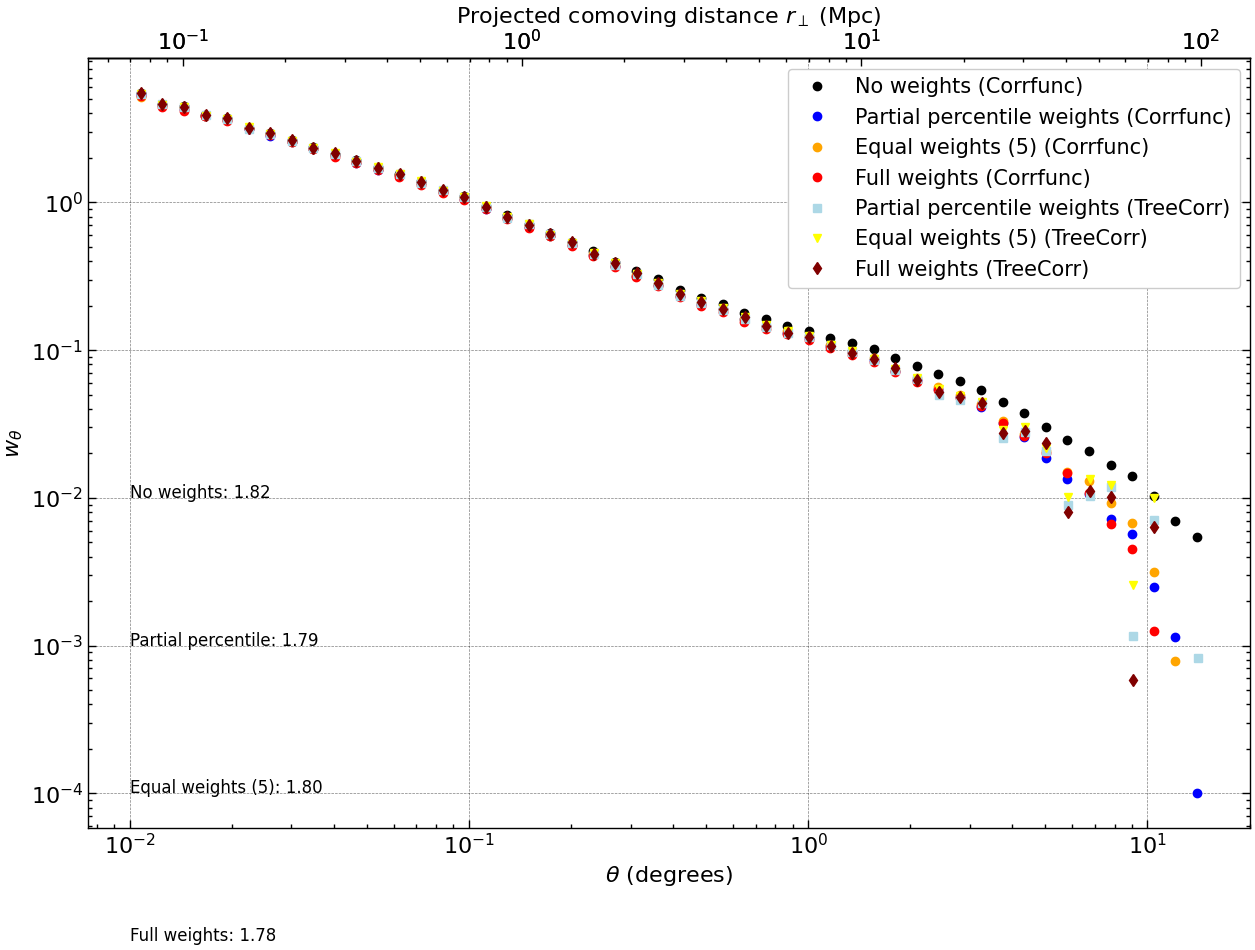

In [11]:
fig, ax = plt.subplots(figsize=(15,10))



ax.set_xlabel(r'$\theta$ (degrees)')
ax.set_ylabel(r'$w_{\theta}$')
ax.set_xscale('log')
plt.yscale('log')

plt.legend(fontsize=15)


popt_cf_no_weights, pcov_cf_no_weights = cf(w_theta_func, north_cf_no_weights[0], north_cf_no_weights[1], p0=[1.0])
popt_cf_pp, pcov_cf_pp = cf(w_theta_func, north_cf_pp[0], north_cf_pp[1], p0=[1.0])
popt_cf_equal_5, pcov_cf_equal_5 = cf(w_theta_func, north_cf_equal_5[0], north_cf_equal_5[1], p0=[1.0])
popt_cf_full, pcov_cf_full = cf(w_theta_func, north_cf_full[0], north_cf_full[1], p0=[1.0])

plt.text(0.01, 1e-2, f'No weights: {popt_cf_no_weights[0]:.2f}', fontsize=12)
plt.text(0.01, 1e-3, f'Partial percentile: {popt_cf_pp[0]:.2f}', fontsize=12)
plt.text(0.01, 1e-4, f'Equal weights (5): {popt_cf_equal_5[0]:.2f}', fontsize=12)
plt.text(0.01, 1e-5, f'Full weights: {popt_cf_full[0]:.2f}', fontsize=12)

plt.loglog(north_cf_no_weights[0],north_cf_no_weights[1],'o',label='No weights (Corrfunc)',color='black')
plt.loglog(north_cf_pp[0],north_cf_pp[1],'o',label='Partial percentile weights (Corrfunc)',color='blue')
#plt.loglog(north_cf_equal_10[0],north_cf_equal_10[1],'^',label='Equal weights (10) (Corrfunc)',color='green')
plt.loglog(north_cf_equal_5[0],north_cf_equal_5[1],'o',label='Equal weights (5) (Corrfunc)',color='orange')
plt.loglog(north_cf_full[0],north_cf_full[1],'o',label='Full weights (Corrfunc)',color='red')



plt.loglog(north_pp[0],north_pp[1],'s',label='Partial percentile weights (TreeCorr)',color='lightblue')
#plt.loglog(north_cf_equal_10[0],north_cf_equal_10[1],'^',label='Equal weights (10) (Corrfunc)',color='green')  
plt.loglog(north_equal_5[0],north_equal_5[1],'v',label='Equal weights (5) (TreeCorr)',color='yellow')
plt.loglog(north_full[0],north_full[1],'d',label='Full weights (TreeCorr)',color='maroon')
plt.legend(fontsize=15)
#### Adding secondary x-axis for projected comoving distance ####
secax = ax.secondary_xaxis('top',
functions=(theta_to_r_dc,r_to_theta_dc))
secax.set_xlabel(r'Projected comoving distance $r_\perp$ (Mpc)')
secax = ax.secondary_xaxis('top', functions=(theta_to_r_dc, r_to_theta_dc))
secax.tick_params(axis='x', which='both', length=0)  # removes the tick marks, keeps labels
ax.tick_params(axis='x', which='both', bottom=True, top=False, labelbottom=True)



/tmp/ipykernel_2649888/1376730041.py:14: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(fontsize=15)


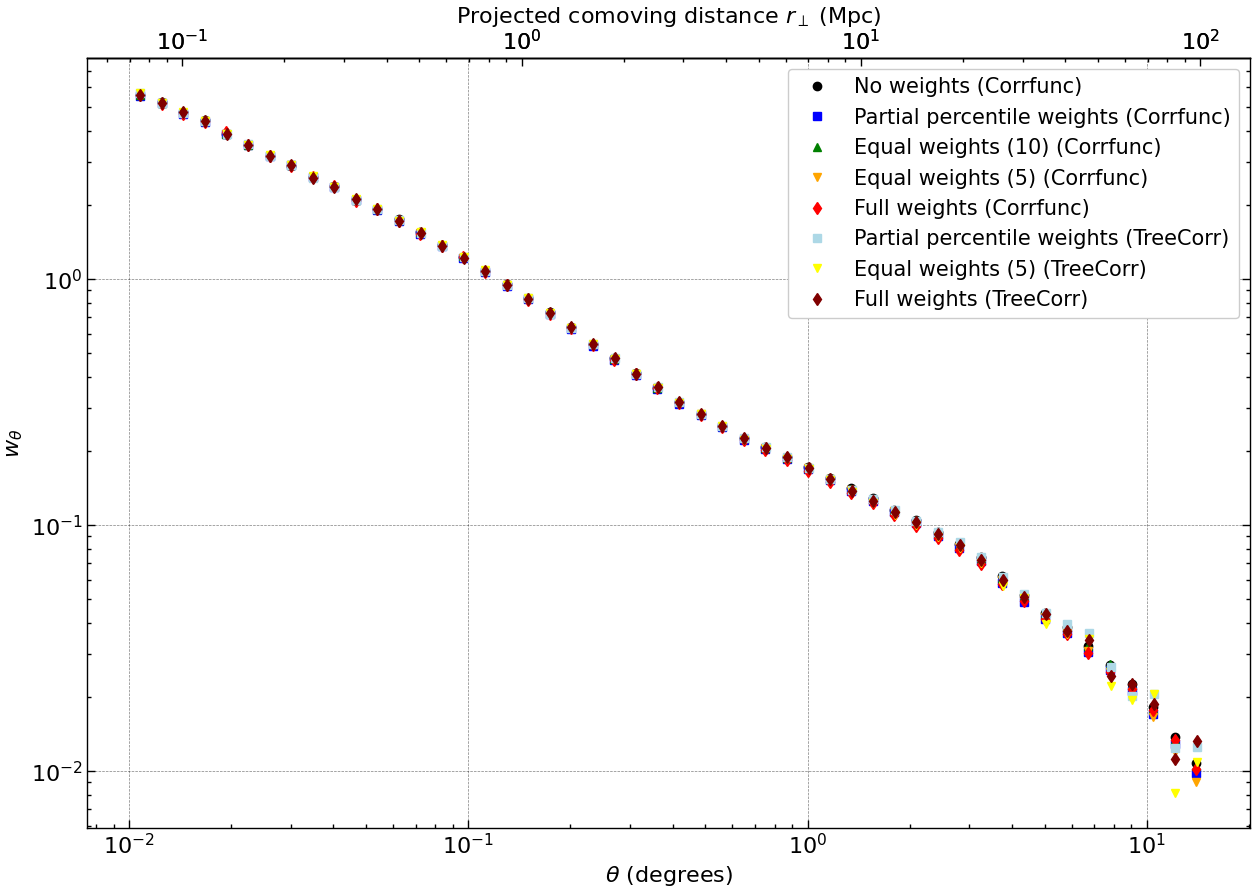

In [12]:
fig, ax = plt.subplots(figsize=(15,10))



ax.set_xlabel(r'$\theta$ (degrees)')
ax.set_ylabel(r'$w_{\theta}$')
ax.set_xscale('log')
plt.yscale('log')
# plt.loglog(full_no_weights[0],full_no_weights[1],'o',label='No weights',color='black')
# plt.loglog(full_pp[0],full_pp[1],'s',label='Partial percentile weights',color='blue')
# plt.loglog(full_equal_10[0],full_equal_10[1],'^',label='Equal weights (10)',color='green')
# plt.loglog(full_equal_5[0],full_equal_5[1],'v',label='Equal weights (5)',color='orange')
# plt.loglog(full_full[0],full_full[1],'d',label='Full weights',color='red')
plt.legend(fontsize=15)


plt.loglog(full_cf_no_weights[0],full_cf_no_weights[1],'o',label='No weights (Corrfunc)',color='black')
plt.loglog(full_cf_pp[0],full_cf_pp[1],'s',label='Partial percentile weights (Corrfunc)',color='blue')
plt.loglog(full_cf_equal_10[0],full_cf_equal_10[1],'^',label='Equal weights (10) (Corrfunc)',color='green')
plt.loglog(full_cf_equal_5[0],full_cf_equal_5[1],'v',label='Equal weights (5) (Corrfunc)',color='orange')
plt.loglog(full_cf_full[0],full_cf_full[1],'d',label='Full weights (Corrfunc)',color='red')
plt.loglog(full_pp[0],full_pp[1],'s',label='Partial percentile weights (TreeCorr)',color='lightblue')
plt.loglog(full_equal_5[0],full_equal_5[1],'v',label='Equal weights (5) (TreeCorr)',color='yellow')
plt.loglog(full_full[0],full_full[1],'d',label='Full weights (TreeCorr)',color='maroon')
plt.legend(fontsize=15)
#### Adding secondary x-axis for projected comoving distance ####
secax = ax.secondary_xaxis('top',
functions=(theta_to_r_dc,r_to_theta_dc))
secax.set_xlabel(r'Projected comoving distance $r_\perp$ (Mpc)')
secax = ax.secondary_xaxis('top', functions=(theta_to_r_dc, r_to_theta_dc))
secax.tick_params(axis='x', which='both', length=0)  # removes the tick marks, keeps labels
ax.tick_params(axis='x', which='both', bottom=True, top=False, labelbottom=True)



In [13]:
plt.hist(weights_full, bins=50,histtype='step',label='Full sample weights',color='maroon',density=True)
plt.hist(weights_north, bins=50,histtype='step',label='North sample weights',color='blue',density=True)
plt.hist(weights_south, bins=50,histtype='step',label='South sample weights',color='green',density=True)

NameError: name 'weights_full' is not defined

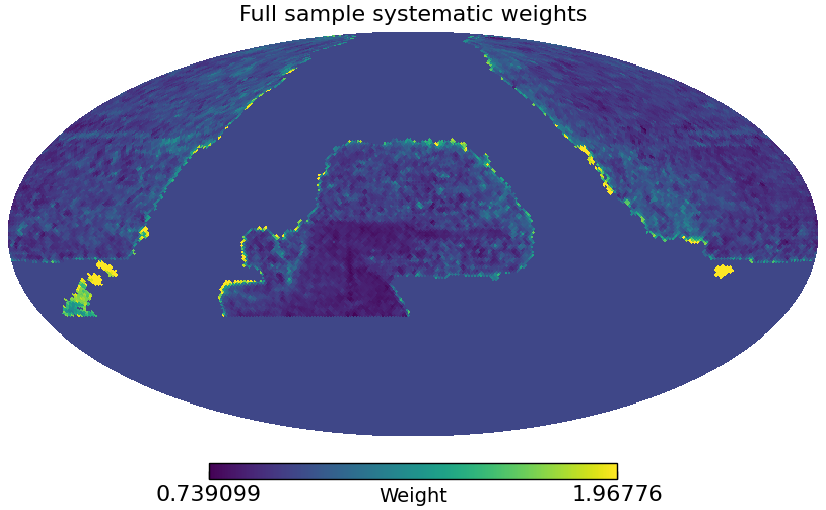

In [14]:
import healpy as hp
weights_full  = hp.read_map(f'/user/animesh.sah/DESI_PECVEL/systematic_weights/full_multilinear_systematic_weights_nside64_full_sample.fits')
weights_north = hp.read_map(f'/user/animesh.sah/DESI_PECVEL/systematic_weights/north_multilinear_systematic_weights_nside64_full_sample.fits')
weights_south = hp.read_map(f'/user/animesh.sah/DESI_PECVEL/systematic_weights/south_multilinear_systematic_weights_nside64_full_sample.fits')
hp.mollview(hp.read_map(f'/user/animesh.sah/DESI_PECVEL/systematic_weights/full_multilinear_systematic_weights_nside64_full_sample.fits'), title='Full sample systematic weights', unit='Weight', cmap='viridis')

In [15]:
weights = hp.read_map(f'/user/animesh.sah/DESI_PECVEL/systematic_weights/north_multilinear_systematic_weights_nside64_full_sample.fits')

In [16]:
print("min weight:", weights.min())
print("max weight:", weights.max())
print("mean weight:", weights.mean())
print("std weight:", weights.std())

min weight: 0.48850389254133936
max weight: 1.9540155701653574
mean weight: 1.0
std weight: 0.05881713709444074


In [ ]:
/user/animesh.sah/w_theta_results/treecorr_north_jackknife_patches_30_0.01_to_15_w_True_full_sample.npy

In [17]:
w_theta_dict1= {}
parts = ['full', 'north', 'south']
errors = ['bootstrap', 'jackknife']
weights= [ 'partial_percentile', 'equal_5', 'full_sample']

bias_dict= {}
upper_scale=15
lower_scale=0.9

for part in parts:
    w_theta_dict1[part] = {}
    bias_dict[part] = {}
    for error in errors:
        w_theta_dict1[part][error] = {}
        bias_dict[part][error] = {}
        for weight in weights:
            if error == 'bootstrap':
                w_theta_dict1[part][error][weight] = np.load(f'/user/animesh.sah/w_theta_results/treecorr_{part}_{error}_patches_30_1000_1000_0.01_to_15_w_True_{weight}.npy')

            else: 
                w_theta_dict1[part][error][weight] = np.load(f'/user/animesh.sah/w_theta_results/treecorr_{part}_{error}_patches_30_0.01_to_15_w_True_{weight}.npy')

            mask = (w_theta_dict1[part][error][weight][0] >= lower_scale) & (w_theta_dict1[part][error][weight][0] <= upper_scale)
            popt,pcov = cf(w_theta_func, w_theta_dict1[part][error][weight][0][mask], w_theta_dict1[part][error][weight][1][mask], p0=[1.0])
            bias_dict[part][error][weight] = popt[0]
        if error == 'bootstrap':
            w_theta_dict1[part][error]['no_weights'] = np.load(f'/user/animesh.sah/w_theta_results/treecorr_{part}_{error}_patches_30_1000_1000_0.01_to_15_w_False_no_weights.npy')
        else:
            w_theta_dict1[part][error]['no_weights'] = np.load(f'/user/animesh.sah/w_theta_results/treecorr_{part}_{error}_patches_30_0.01_to_15_w_False_no_weights.npy')
        bias_dict[part][error]['no_weights'] = cf(w_theta_func, w_theta_dict1[part][error]['no_weights'][0][mask], w_theta_dict1[part][error]['no_weights'][1][mask], p0=[1.0])[0][0]

In [37]:
np.hstack([errors, ['no_weights']])

array(['bootstrap', 'jackknife', 'no_weights'], dtype='<U10')

In [40]:
label=f'{error}, {weight} (b={b:.2f})'

TypeError: unsupported format string passed to numpy.ndarray.__format__

In [49]:
label=f'{error}, {weight} '
label

'jackknife, no_weights '

In [54]:
np.hstack([weights, ['no_weights']])

array(['partial_percentile', 'equal_5', 'full_sample', 'no_weights'],
      dtype='<U18')

1.8631261422697607
1.866471350628337
1.8764483903148423
1.882353047423185


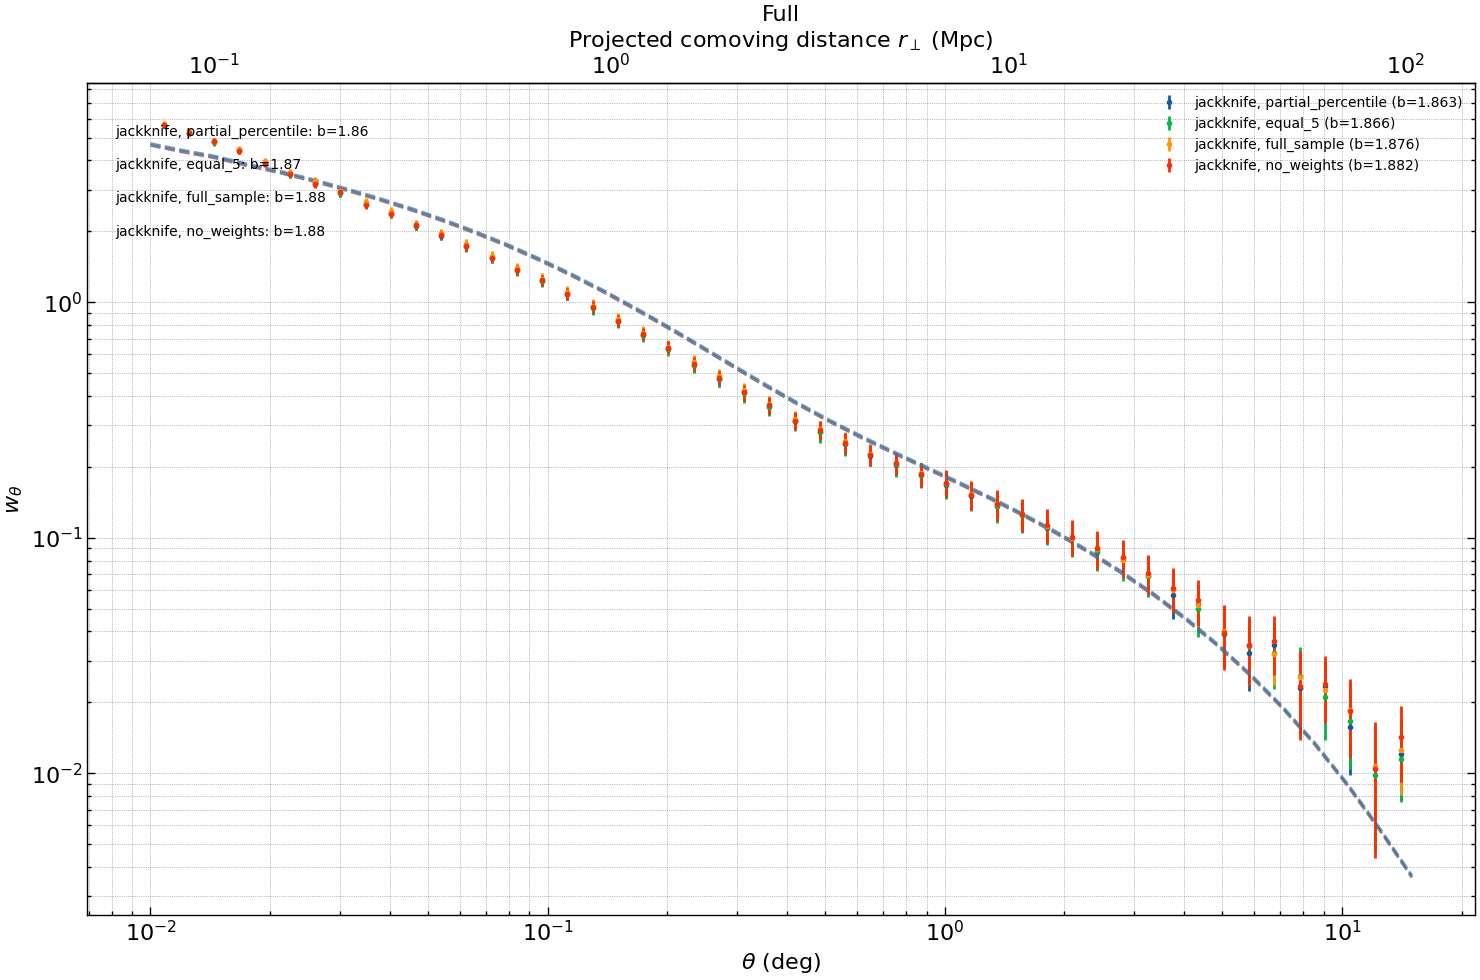

1.5312830076387236
1.5495093053084954
1.5224879852556141
1.663139101613768


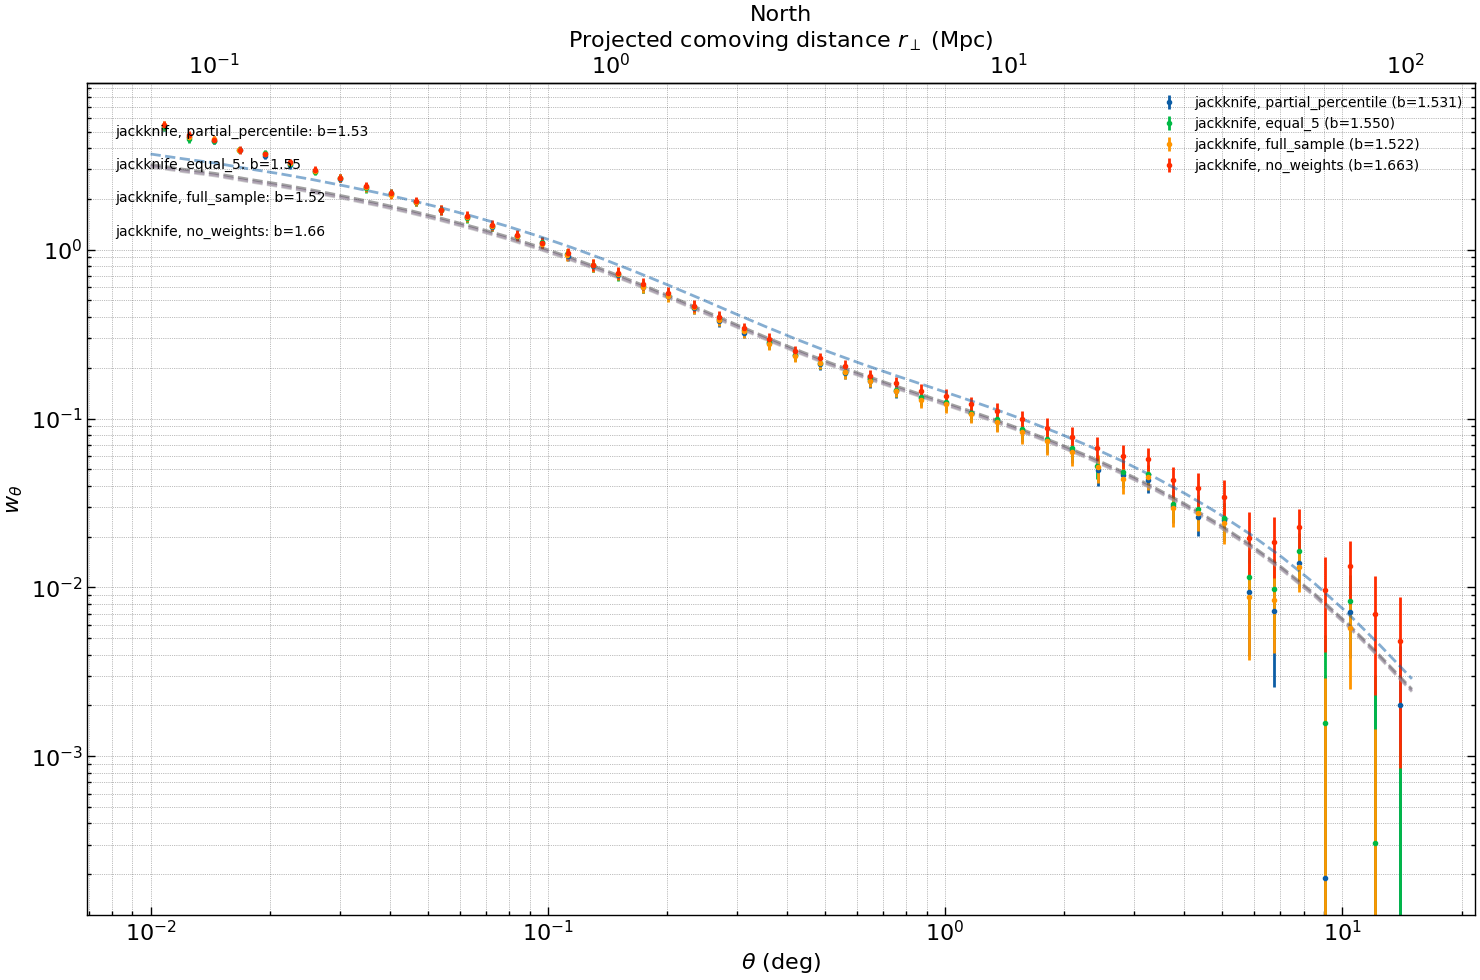

1.823707434674089
1.8369431362754856
1.7868732005177135
1.9015308638452533


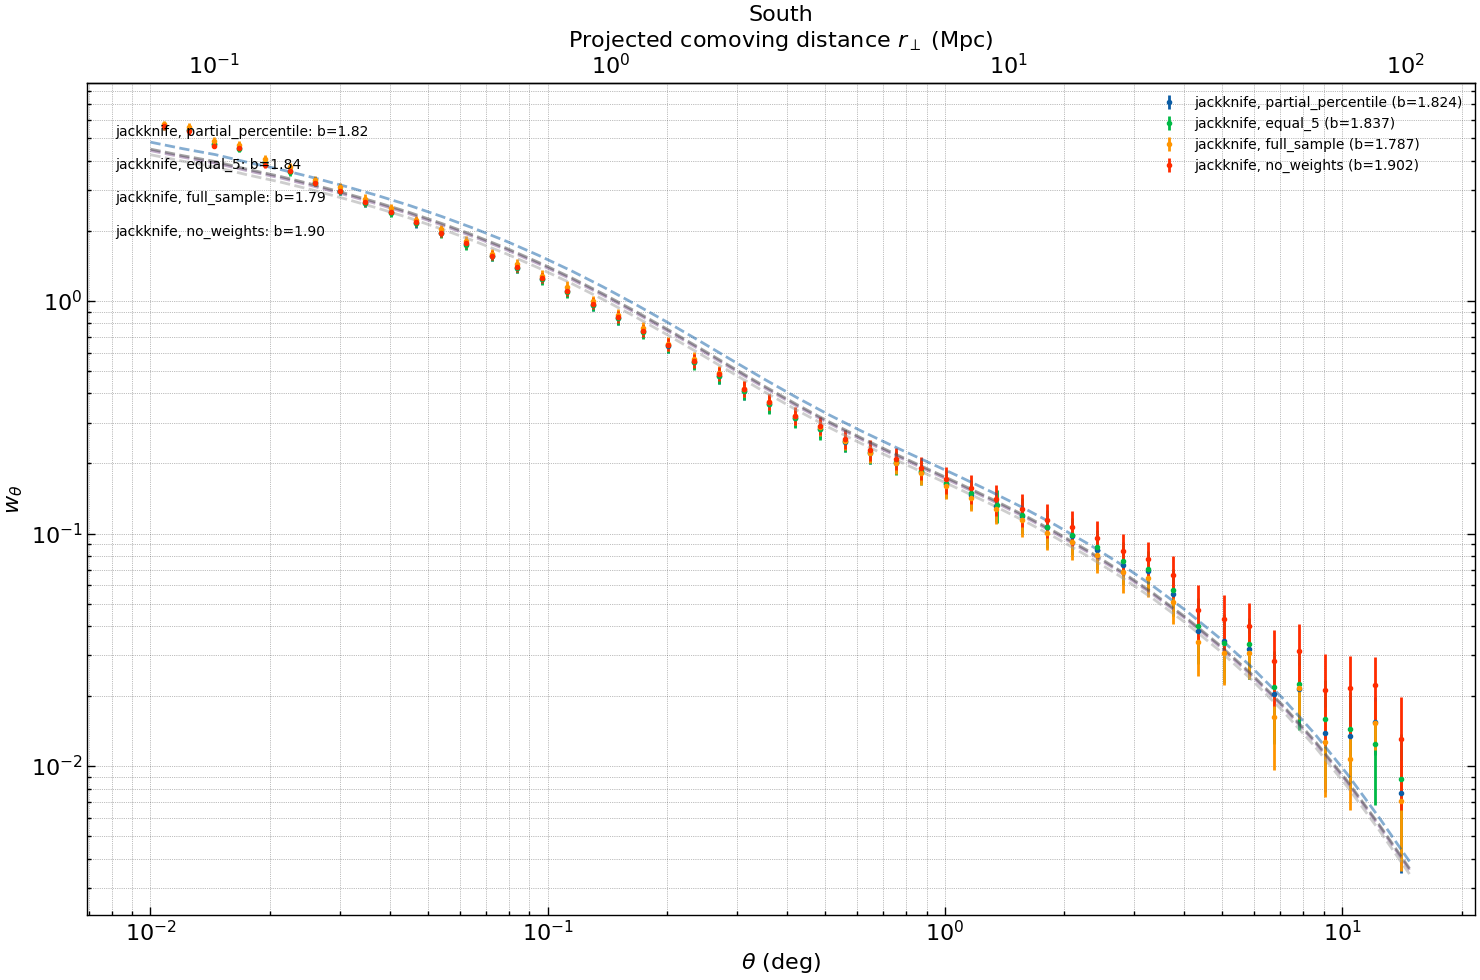

In [57]:
errors = ['jackknife']

for part in parts:
    fig, ax = plt.subplots(figsize=(15, 10))

    for error in errors:
        style = error_styles[error]
        for weight in np.hstack([weights, ['no_weights']]):
            th = w_theta_dict1[part][error][weight][0]
            wt = w_theta_dict1[part][error][weight][1]
            er = w_theta_dict1[part][error][weight][2]
            b = bias_dict[part][error][weight]
            print(b)
            ax.errorbar(
                th, wt, yerr=er, markersize=3,
                label=f'{error}, {weight} (b={b:.3f})', ls='None',marker='o'
            )
    # Fit bias for each combination and overlay the best-fit model
    for error in errors:
        for weight in np.hstack([weights, ['no_weights']]):
            b = bias_dict[part][error][weight]
            wtheta_model = w_theta_func(theta, b)
            ax.plot(theta, wtheta_model, ls='--', alpha=0.5)

    # Add bias text annotation
    y_pos = 0.95
    for error in errors:
        for weight in np.hstack([weights, ['no_weights']]):
            b = bias_dict[part][error][weight]
            ax.text(0.02, y_pos, f'{error}, {weight}: b={b:.2f}',
                    transform=ax.transAxes, fontsize=10, verticalalignment='top')
            y_pos -= 0.04
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_title(part.capitalize())
    ax.set_xlabel(r'$\theta$ (deg)')
    ax.set_ylabel(r'$w_\theta$')
    ax.grid(True, which='both', ls=':', alpha=0.5)
    ax.legend(fontsize=10, frameon=False)

    secax = ax.secondary_xaxis('top', functions=(theta_to_r_dc, r_to_theta_dc))
    secax.set_xlabel(r'Projected comoving distance $r_\perp$ (Mpc)')
    secax.tick_params(axis='x', which='both', length=0)
    ax.tick_params(axis='x', which='both', bottom=True, top=False, labelbottom=True)

    plt.tight_layout()
    plt.show()


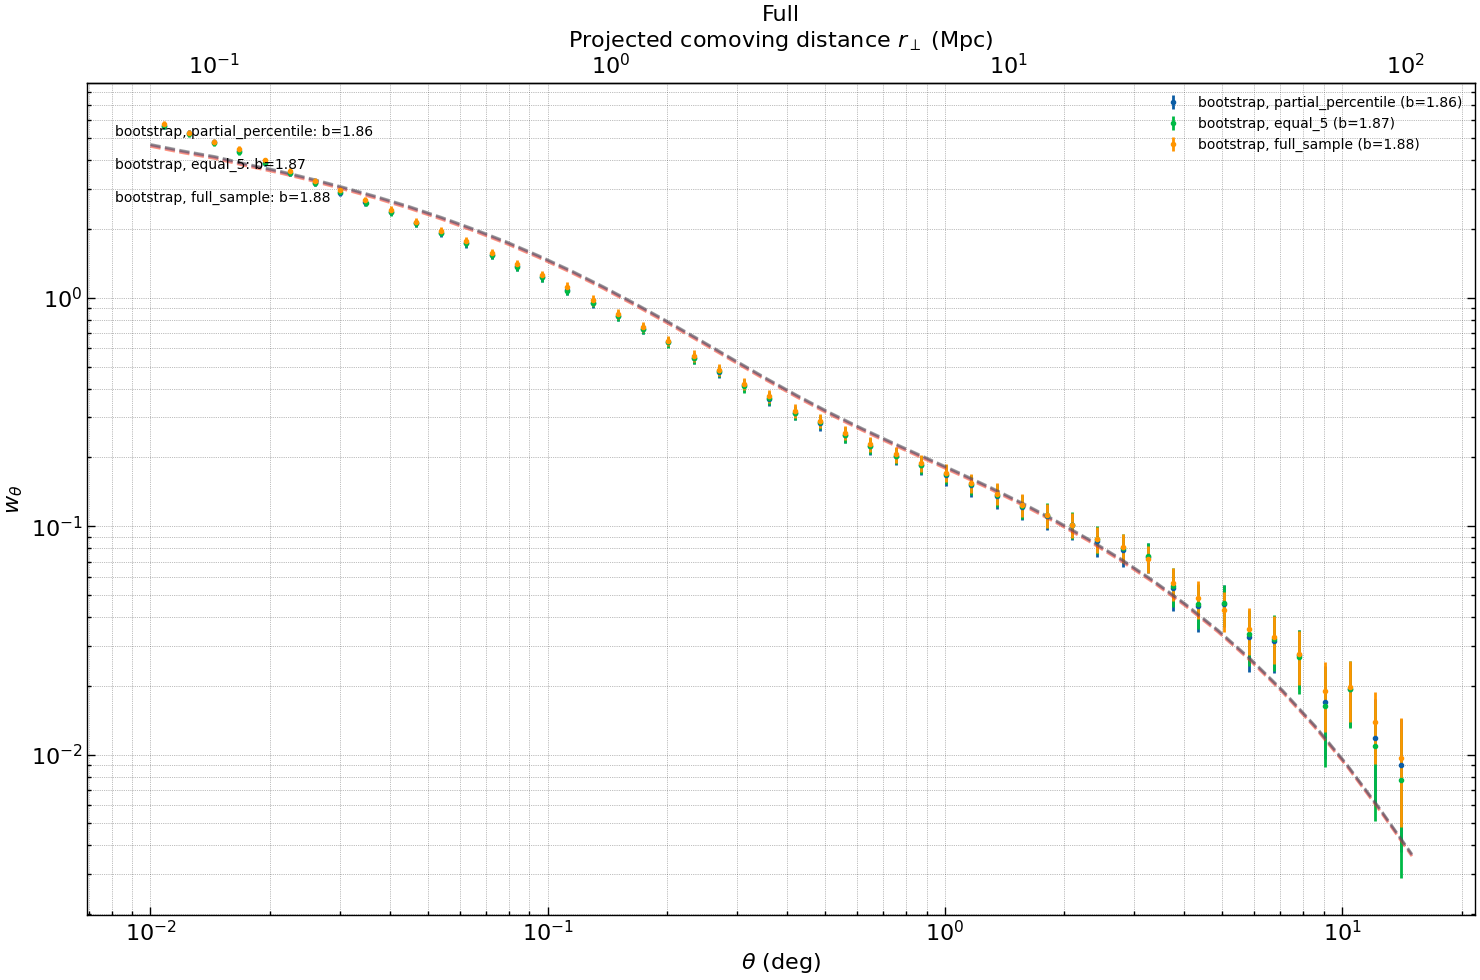

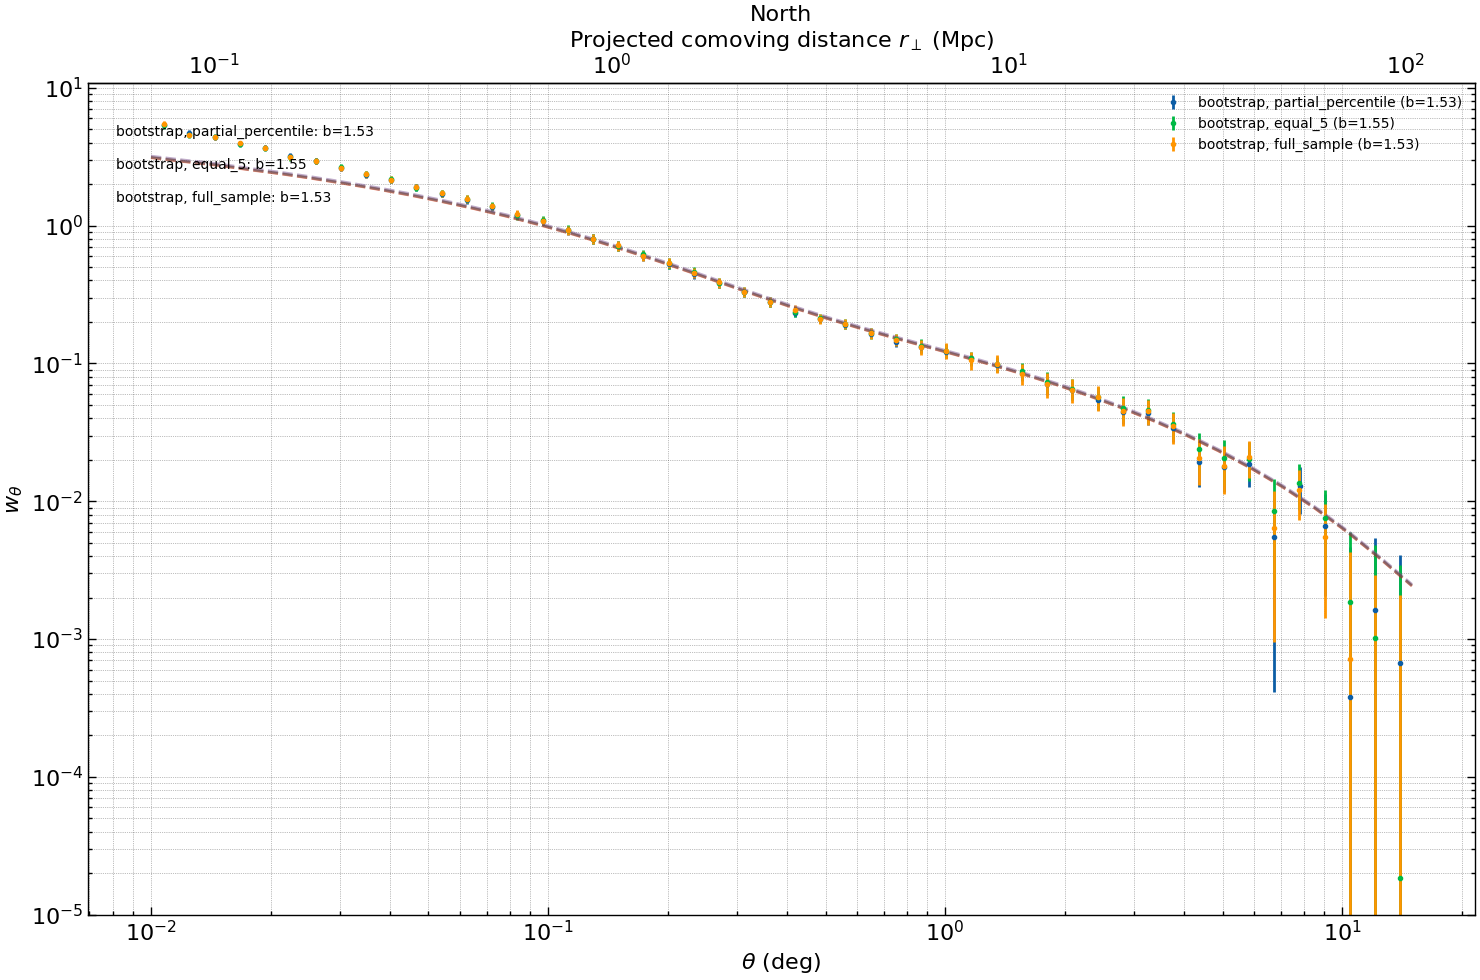

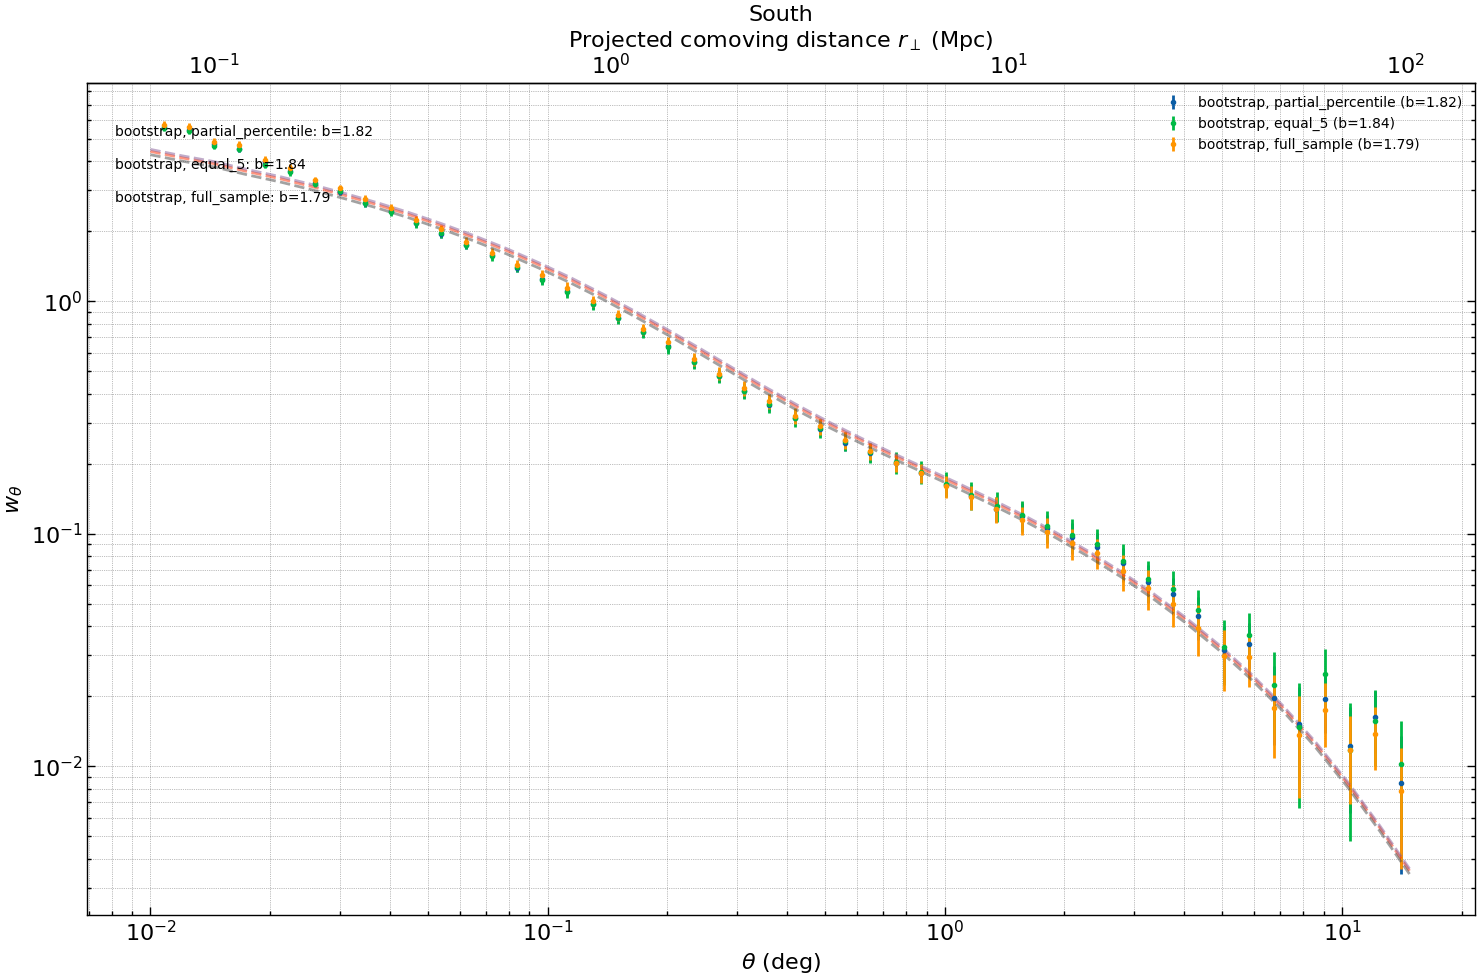

In [30]:
errors = ['bootstrap']
for part in parts:
    fig, ax = plt.subplots(figsize=(15, 10))

    for error in errors:
        style = error_styles[error]
        for weight in weights:
            th = w_theta_dict1[part][error][weight][0]
            wt = w_theta_dict1[part][error][weight][1]
            er = w_theta_dict1[part][error][weight][2]
            b = bias_dict[part][error][weight]
            ax.errorbar(
                th, wt, yerr=er, markersize=3,
                label=f'{error}, {weight} (b={b:.2f})', ls='None',marker='o'
            )
    # Fit bias for each combination and overlay the best-fit model
    for error in errors:
        for weight in weights:
            b = bias_dict[part][error][weight]
            wtheta_model = w_theta_func(theta, b)
            ax.plot(theta, wtheta_model, ls='--', alpha=0.5)

    # Add bias text annotation
    y_pos = 0.95
    for error in errors:
        for weight in weights:
            b = bias_dict[part][error][weight]
            ax.text(0.02, y_pos, f'{error}, {weight}: b={b:.2f}',
                    transform=ax.transAxes, fontsize=10, verticalalignment='top')
            y_pos -= 0.04
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_title(part.capitalize())
    ax.set_xlabel(r'$\theta$ (deg)')
    ax.set_ylabel(r'$w_\theta$')
    ax.grid(True, which='both', ls=':', alpha=0.5)
    ax.legend(fontsize=10, frameon=False)

    secax = ax.secondary_xaxis('top', functions=(theta_to_r_dc, r_to_theta_dc))
    secax.set_xlabel(r'Projected comoving distance $r_\perp$ (Mpc)')
    secax.tick_params(axis='x', which='both', length=0)
    ax.tick_params(axis='x', which='both', bottom=True, top=False, labelbottom=True)

    plt.tight_layout()
    plt.show()


In [15]:
north_csfd = np.load('/user/animesh.sah/w_theta_results/treecorr_north_bootstrap_patches_30_1000_1000_0.01_to_15_w_True_csfd_only.npy')
full_csfd = np.load('/user/animesh.sah/w_theta_results/treecorr_full_bootstrap_patches_30_1000_1000_0.01_to_15_w_True_csfd_only.npy')
south_csfd = np.load('/user/animesh.sah/w_theta_results/treecorr_south_bootstrap_patches_30_1000_1000_0.01_to_15_w_True_csfd_only.npy')

In [1]:
fig, ax = plt.subplots(figsize=(15, 10))

ax.set_xlabel(r'$\theta$ (degrees)')
ax.set_ylabel(r'$w_{\theta}$')
ax.set_xscale('log')
ax.set_yscale('log')
upper_scale=15
lower_scale=0.9
# Fit bias for each
mask_csfd = (full_csfd[0] >= lower_scale) & (full_csfd[0] <= upper_scale)
popt_full_csfd, _ = cf(w_theta_func, full_csfd[0][mask_csfd], full_csfd[1][mask_csfd], p0=[1.0])
popt_north_csfd, _ = cf(w_theta_func, north_csfd[0][mask_csfd], north_csfd[1][mask_csfd], p0=[1.0])
popt_south_csfd, _ = cf(w_theta_func, south_csfd[0][mask_csfd], south_csfd[1][mask_csfd], p0=[1.0])

# Plot data with errorbars

plt.loglog(full_cf_no_weights[0],full_cf_no_weights[1],'o',label='No weights  full(Corrfunc)',color='gray')
plt.loglog(north_cf_no_weights[0],north_cf_no_weights[1],'o',label='No weights north (Corrfunc)',color='slateblue'
           )
plt.loglog(south_cf_no_weights[0],south_cf_no_weights[1],'o',label='No weights south (Corrfunc)',color='cyan')
ax.errorbar(full_csfd[0], full_csfd[1], yerr=full_csfd[2], fmt='o', label=f'Full CSFD (b={popt_full_csfd[0]:.3f})', color='black', markersize=4)
ax.errorbar(north_csfd[0], north_csfd[1], yerr=north_csfd[2], fmt='s', label=f'North CSFD (b={popt_north_csfd[0]:.3f})', color='blue', markersize=4)
ax.errorbar(south_csfd[0], south_csfd[1], yerr=south_csfd[2], fmt='^', label=f'South CSFD (b={popt_south_csfd[0]:.3f})', color='red', markersize=4)

# Plot best-fit models
ax.plot(theta, w_theta_func(theta, popt_full_csfd[0]), '--', color='black', alpha=0.5)
ax.plot(theta, w_theta_func(theta, popt_north_csfd[0]), '--', color='blue', alpha=0.5)
ax.plot(theta, w_theta_func(theta, popt_south_csfd[0]), '--', color='red', alpha=0.5)

ax.legend(fontsize=15)
ax.grid(True, which='both', ls=':', alpha=0.5)

# Secondary x-axis
secax = ax.secondary_xaxis('top', functions=(theta_to_r_dc, r_to_theta_dc))
secax.set_xlabel(r'Projected comoving distance $r_\perp$ (Mpc)')
secax.tick_params(axis='x', which='both', length=0)
ax.tick_params(axis='x', which='both', bottom=True, top=False, labelbottom=True)

plt.tight_layout()
plt.show()

NameError: name 'plt' is not defined

### Newer sample defined


In [22]:



#south_no_weights = np.load('/user/animesh.sah/w_theta_results/treecorr_south_0.01_to_15_w_False_no_weights.npy')

north_pp = np.load('/user/animesh.sah/w_theta_results/treecorr_north_bootstrap_patches_30_1000_1000_0.01_to_15_w_True_partial_percentile.npy')
north_equal_5 = np.load('/user/animesh.sah/w_theta_results/treecorr_north_bootstrap_patches_30_1000_1000_0.01_to_15_w_True_equal_5.npy')
north_full = np.load('/user/animesh.sah/w_theta_results/treecorr_north_bootstrap_patches_30_1000_1000_0.01_to_15_w_True_full_sample.npy')
north_no_weights = np.load('/user/animesh.sah/w_theta_results/treecorr_full_bootstrap_patches_30_1000_1000_0.01_to_15_w_False_.npy')

south_pp = np.load('/user/animesh.sah/w_theta_results/treecorr_south_bootstrap_patches_30_1000_1000_0.01_to_15_w_True_partial_percentile.npy')
south_equal_5 = np.load('/user/animesh.sah/w_theta_results/treecorr_south_bootstrap_patches_30_1000_1000_0.01_to_15_w_True_equal_5.npy')
south_full = np.load('/user/animesh.sah/w_theta_results/treecorr_south_bootstrap_patches_30_1000_1000_0.01_to_15_w_True_full_sample.npy')
south_no_weights = np.load('/user/animesh.sah/w_theta_results/treecorr_south_bootstrap_patches_30_1000_1000_0.01_to_15_w_False_.npy')


full_pp = np.load('/user/animesh.sah/w_theta_results/treecorr_full_bootstrap_patches_30_1000_1000_0.01_to_15_w_True_partial_percentile.npy')
full_equal_5 = np.load('/user/animesh.sah/w_theta_results/treecorr_full_bootstrap_patches_30_1000_1000_0.01_to_15_w_True_equal_5.npy')
full_full = np.load('/user/animesh.sah/w_theta_results/treecorr_full_bootstrap_patches_30_1000_1000_0.01_to_15_w_True_full_sample.npy')
full_no_weights = np.load('/user/animesh.sah/w_theta_results/treecorr_full_bootstrap_patches_30_1000_1000_0.01_to_15_w_False_no_weights.npy')   

In [31]:
north_pp

array([[1.07993178e-02, 1.25000182e-02, 1.44711972e-02, 1.67412480e-02,
        1.93818368e-02, 2.24348863e-02, 2.59940530e-02, 3.00191537e-02,
        3.48095263e-02, 4.02778121e-02, 4.65934923e-02, 5.40096471e-02,
        6.24953900e-02, 7.23275113e-02, 8.37041404e-02, 9.68860637e-02,
        1.12184854e-01, 1.29772024e-01, 1.50313984e-01, 1.73967383e-01,
        2.01429387e-01, 2.33156213e-01, 2.69801993e-01, 3.12399664e-01,
        3.61530790e-01, 4.18484054e-01, 4.84498989e-01, 5.60969330e-01,
        6.49126095e-01, 7.51553761e-01, 8.70099134e-01, 1.00709237e+00,
        1.16573789e+00, 1.34967104e+00, 1.56217155e+00, 1.80825762e+00,
        2.09314642e+00, 2.42305118e+00, 2.80490459e+00, 3.24662104e+00,
        3.75851823e+00, 4.35133292e+00, 5.03691354e+00, 5.83184638e+00,
        6.75143416e+00, 7.81361965e+00, 9.04218209e+00, 1.04644594e+01,
        1.21164269e+01, 1.40320911e+01],
       [5.39491952e+00, 4.48010747e+00, 4.28739740e+00, 3.84520560e+00,
        3.54918410e+00,

In [30]:
w_theta_dict1['north']['bootstrap']['partial_percentile'] 

array([[1.07993178e-02, 1.25000182e-02, 1.44711972e-02, 1.67412480e-02,
        1.93818368e-02, 2.24348863e-02, 2.59940530e-02, 3.00191537e-02,
        3.48095263e-02, 4.02778121e-02, 4.65934923e-02, 5.40096471e-02,
        6.24953900e-02, 7.23275113e-02, 8.37041404e-02, 9.68860637e-02,
        1.12184854e-01, 1.29772024e-01, 1.50313984e-01, 1.73967383e-01,
        2.01429387e-01, 2.33156213e-01, 2.69801993e-01, 3.12399664e-01,
        3.61530790e-01, 4.18484054e-01, 4.84498989e-01, 5.60969330e-01,
        6.49126095e-01, 7.51553761e-01, 8.70099134e-01, 1.00709237e+00,
        1.16573789e+00, 1.34967104e+00, 1.56217155e+00, 1.80825762e+00,
        2.09314642e+00, 2.42305118e+00, 2.80490459e+00, 3.24662104e+00,
        3.75851823e+00, 4.35133292e+00, 5.03691354e+00, 5.83184638e+00,
        6.75143416e+00, 7.81361965e+00, 9.04218209e+00, 1.04644594e+01,
        1.21164269e+01, 1.40320911e+01],
       [5.39491952e+00, 4.48010747e+00, 4.28739740e+00, 3.84520560e+00,
        3.54918410e+00,

In [ ]:
w_theta_dict1= {}
parts = ['full', 'north', 'south']
errors = ['bootstrap']
weights= [ 'partial_percentile', 'equal_5', 'full_sample']

bias_dict= {}
upper_scale=15
lower_scale=0.9

for part in parts:
    w_theta_dict1[part] = {}
    bias_dict[part] = {}
    for error in errors:
        w_theta_dict1[part][error] = {}
        bias_dict[part][error] = {}
        for weight in weights:
            if error == 'bootstrap':
                
                w_theta_dict1[part][error][weight] = np.load(f'/user/animesh.sah/w_theta_results/treecorr_{part}_{error}_patches_30_1000_1000_0.01_to_15_w_True_{weight}.npy')
            else: 
                w_theta_dict1[part][error][weight] = np.load(f'/user/animesh.sah/w_theta_results/treecorr_{part}_{error}_patches_30_0.01_to_15_w_True_{weight}.npy')

            mask = (w_theta_dict1[part][error][weight][0] >= lower_scale) & (w_theta_dict1[part][error][weight][0] <= upper_scale)
            popt,pcov = cf(w_theta_func, w_theta_dict1[part][error][weight][0][mask], w_theta_dict1[part][error][weight][1][mask], p0=[1.0])
            bias_dict[part][error][weight] = popt[0]
        if error == 'bootstrap':
            w_theta_dict1[part][error]['no_weights'] = np.load(f'/user/animesh.sah/w_theta_results/treecorr_{part}_{error}_patches_30_1000_1000_0.01_to_15_w_False_no_weights.npy')
        else:
            w_theta_dict1[part][error]['no_weights'] = np.load(f'/user/animesh.sah/w_theta_results/treecorr_{part}_{error}_patches_30_0.01_to_15_w_False_no_weights.npy')
        bias_dict[part][error]['no_weights'] = cf(w_theta_func, w_theta_dict1[part][error]['no_weights'][0][mask], w_theta_dict1[part][error]['no_weights'][1][mask], p0=[1.0])[0][0]

In [34]:
weights

['partial_percentile', 'equal_5', 'full_sample']

In [37]:
np.hstack([weights, ['no_weights']])

array(['partial_percentile', 'equal_5', 'full_sample', 'no_weights'],
      dtype='<U18')

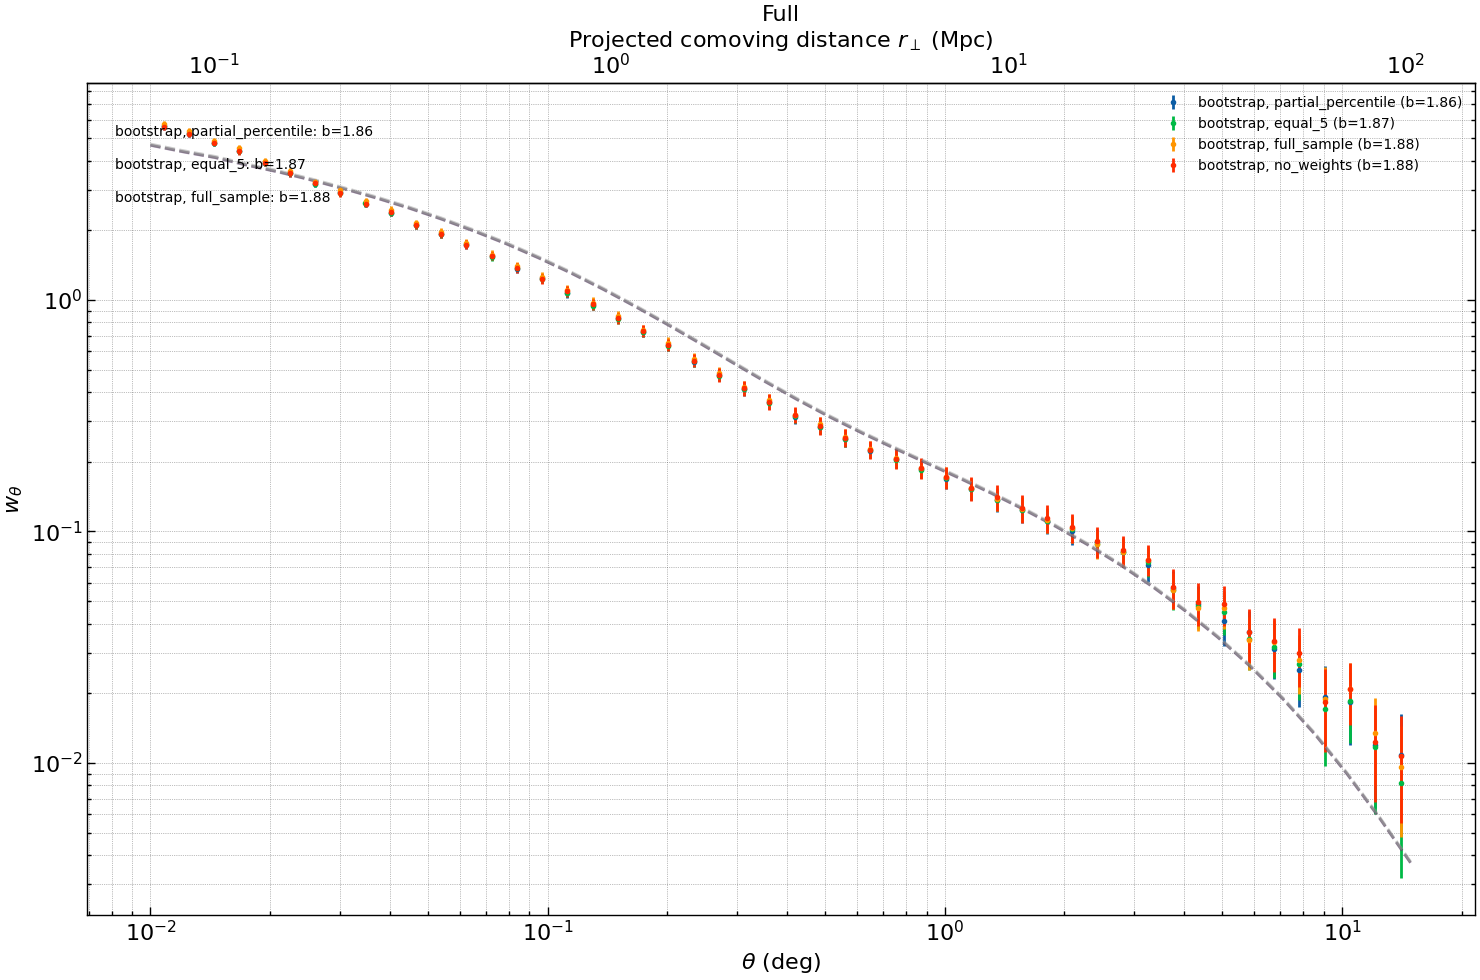

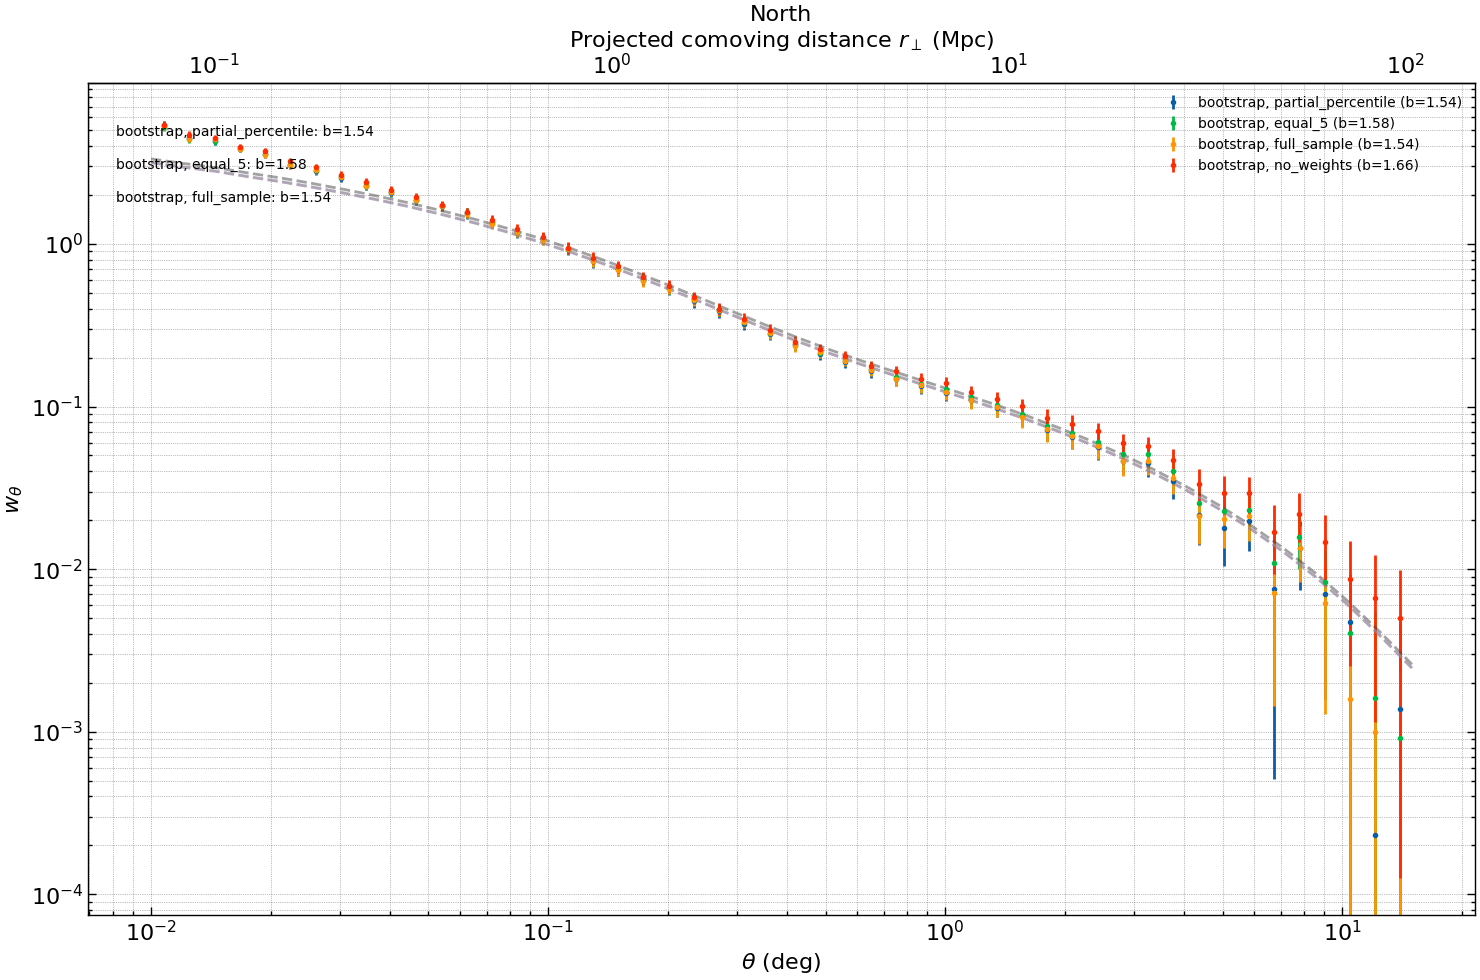

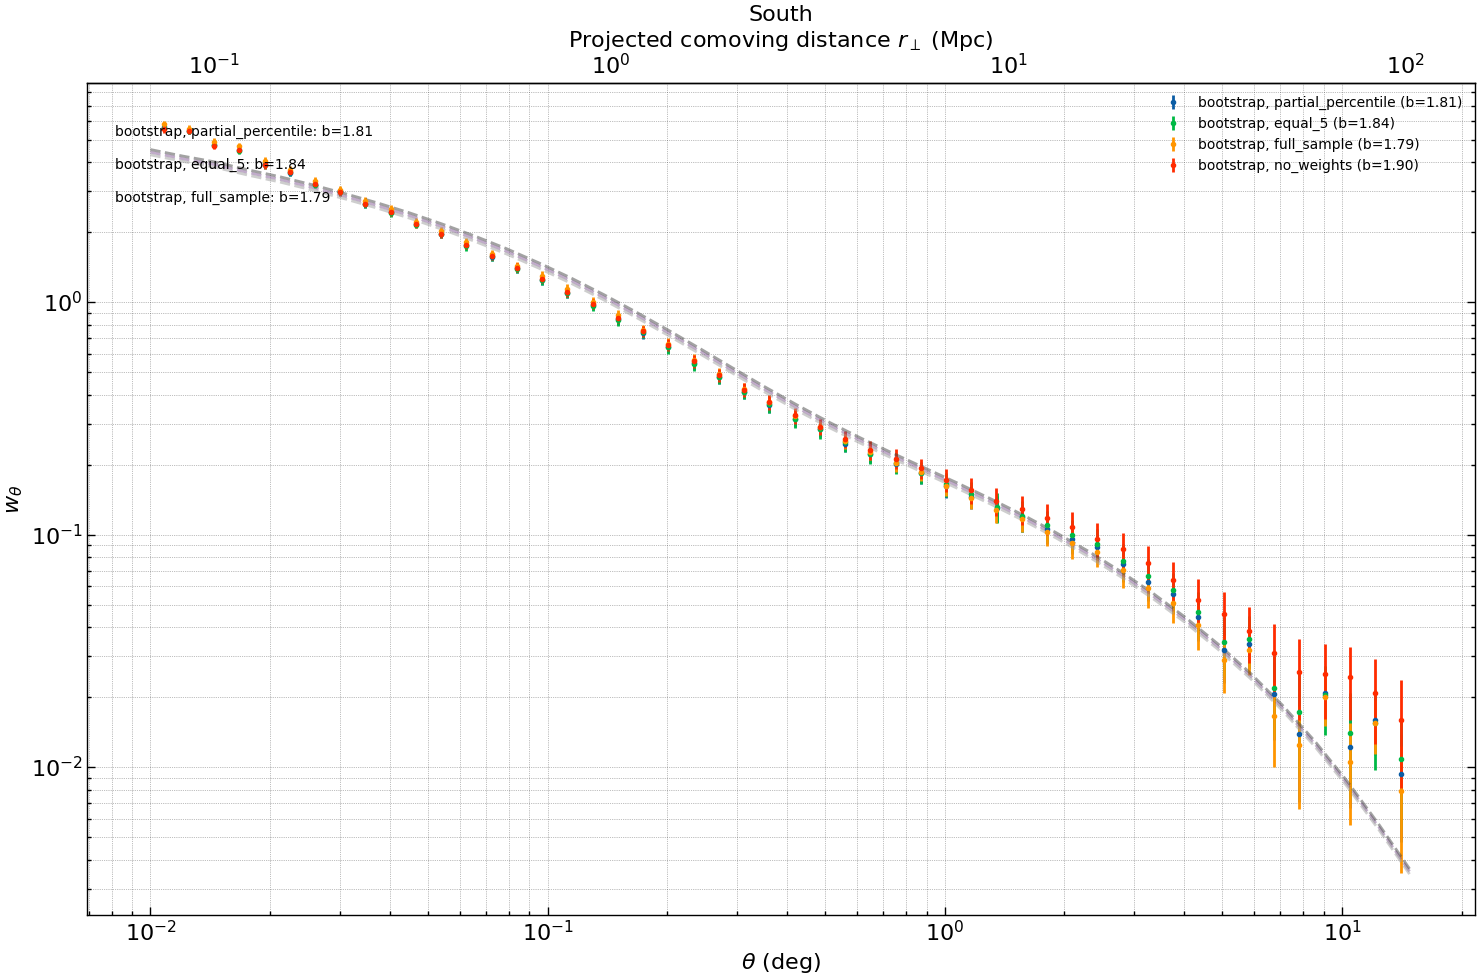

In [38]:
parts = ['full', 'north', 'south']
upper_scale=15
lower_scale=0.9

for part in parts:
    fig, ax = plt.subplots(figsize=(15, 10))


    for weight in np.hstack([weights, ['no_weights']]):
        th = w_theta_dict1[part][error][weight][0]
        wt = w_theta_dict1[part][error][weight][1]
        er = w_theta_dict1[part][error][weight][2]
        b = bias_dict[part][error][weight]
        ax.errorbar(
            th, wt, yerr=er, markersize=3,
            label=f'{error}, {weight} (b={b:.2f})', ls='None',marker='o'
        )
    # Fit bias for each combination and overlay the best-fit model

    for weight in weights:
        b = bias_dict[part][error][weight]
        wtheta_model = w_theta_func(theta, b)
        ax.plot(theta, wtheta_model, ls='--', alpha=0.5)

    # Add bias text annotation
    y_pos = 0.95
    for error in errors:
        for weight in weights:
            b = bias_dict[part][error][weight]
            ax.text(0.02, y_pos, f'{error}, {weight}: b={b:.2f}',
                    transform=ax.transAxes, fontsize=10, verticalalignment='top')
            y_pos -= 0.04
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_title(part.capitalize())
    ax.set_xlabel(r'$\theta$ (deg)')
    ax.set_ylabel(r'$w_\theta$')
    ax.grid(True, which='both', ls=':', alpha=0.5)
    ax.legend(fontsize=10, frameon=False)

    secax = ax.secondary_xaxis('top', functions=(theta_to_r_dc, r_to_theta_dc))
    secax.set_xlabel(r'Projected comoving distance $r_\perp$ (Mpc)')
    secax.tick_params(axis='x', which='both', length=0)
    ax.tick_params(axis='x', which='both', bottom=True, top=False, labelbottom=True)

    plt.tight_layout()
    plt.show()
